# District Beta Diversity (Jaccard)

Compares district-level species composition turnover after spatial thinning.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list
sns.set_theme(style='whitegrid', context='paper')
RANDOM_SEED = 42


In [2]:
p = next((x for x in [Path('file6.csv'), Path('../file6.csv'), Path('../../file6.csv')] if x.exists()), None)
if p is None:
    raise FileNotFoundError('file6.csv not found')
cols = ['stateProvince','verbatimScientificName','decimalLatitude','decimalLongitude','eventDate']
df = pd.read_csv(p, usecols=cols, low_memory=False).dropna(subset=cols)
for c in ['decimalLatitude','decimalLongitude']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna(subset=['decimalLatitude','decimalLongitude'])
df['stateProvince'] = df['stateProvince'].astype(str).str.strip()
df['verbatimScientificName'] = df['verbatimScientificName'].astype(str).str.strip()


In [3]:
lon0 = float(df['decimalLongitude'].median())
lat0 = float(df['decimalLatitude'].median())
lat_rad = np.radians(df['decimalLatitude'].to_numpy())
df['x_km'] = (df['decimalLongitude'].to_numpy() - lon0) * 111.320 * np.cos(lat_rad)
df['y_km'] = (df['decimalLatitude'].to_numpy() - lat0) * 110.574
df['grid_x'] = np.floor(df['x_km'] / 5.0).astype(int)
df['grid_y'] = np.floor(df['y_km'] / 5.0).astype(int)
df['cell_id'] = df['stateProvince'].astype(str) + '|' + df['grid_x'].astype(str) + '_' + df['grid_y'].astype(str)
df['_key'] = df['cell_id'] + '|' + df['verbatimScientificName']
rng = np.random.default_rng(RANDOM_SEED)
df['_r'] = rng.random(len(df))
df_thin = df.sort_values('_r').groupby('_key', as_index=False).head(1)


In [4]:
presence = pd.crosstab(df_thin['stateProvince'], df_thin['verbatimScientificName'])
presence = (presence > 0).astype(int)
dist = pdist(presence.values, metric='jaccard')
jaccard = pd.DataFrame(squareform(dist), index=presence.index, columns=presence.index)
jaccard.head()


stateProvince,Ampara,Anuradhapura,Badulla,Batticaloa,Colombo,Galle,Gampaha,Hambantota,Jaffna,Kalutara,...,Matale,Matara,Monaragala,Mullaittivu,Nuwara,Polonnaruwa,Puttalam,Ratnapura,Trincomalee,Vavuniya
stateProvince,,,,,,,,,,,,,,,,,,,,,
Ampara,0.000000,0.241509,0.424354,0.286325,0.308970,0.293706,0.337500,0.319277,0.342960,0.347826,...,0.303754,0.291262,0.253425,0.311475,0.383838,0.231707,0.287625,0.328076,0.250965,0.397490
Anuradhapura,0.241509,0.000000,0.352273,0.350806,0.282392,0.271777,0.348624,0.320475,0.378472,0.324910,...,0.209220,0.282051,0.219931,0.372093,0.317241,0.161826,0.266667,0.258900,0.286245,0.370833
Badulla,0.424354,0.352273,0.000000,0.537549,0.432787,0.332117,0.486405,0.476879,0.587459,0.346304,...,0.293040,0.396774,0.387205,0.573034,0.279693,0.351020,0.477848,0.358553,0.503546,0.435556
Batticaloa,0.286325,0.350806,0.537549,0.000000,0.425087,0.415441,0.472669,0.477204,0.331950,0.465385,...,0.428571,0.445545,0.421603,0.233831,0.505300,0.327434,0.403509,0.444079,0.300429,0.319588
Colombo,0.308970,0.282392,0.432787,0.425087,0.000000,0.221122,0.233333,0.279661,0.406250,0.269625,...,0.254777,0.229358,0.246875,0.446309,0.330189,0.335616,0.229560,0.244713,0.347541,0.493056


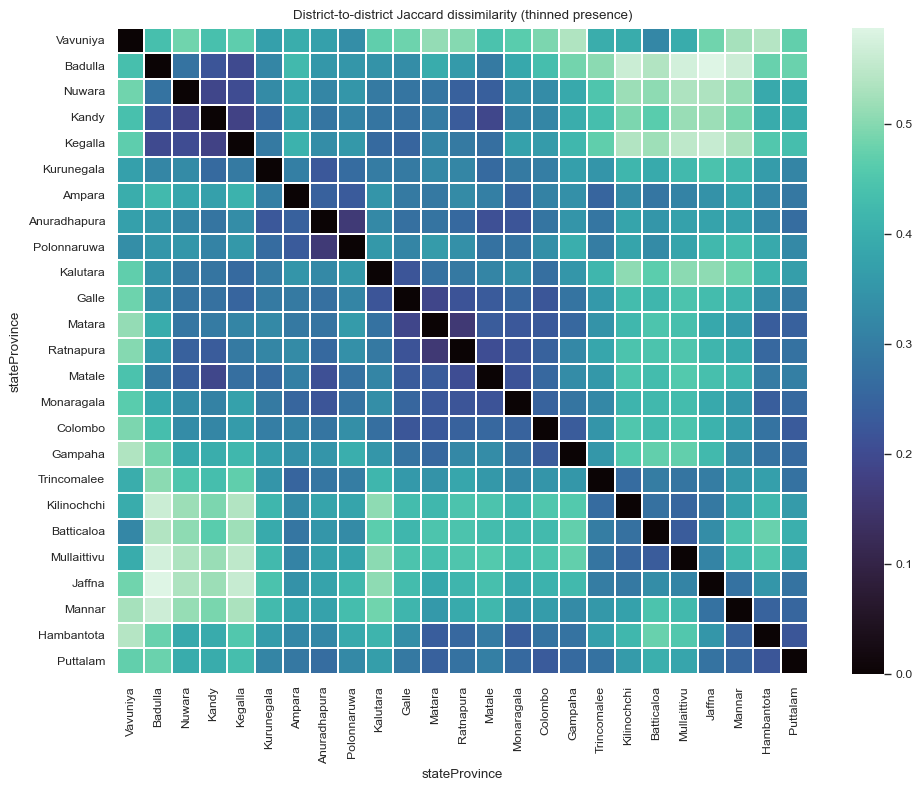

In [5]:
link = linkage(dist, method='average')
order = leaves_list(link)
ordered = jaccard.iloc[order, order]
plt.figure(figsize=(10,8))
sns.heatmap(ordered, cmap='mako', linewidths=0.3)
plt.title('District-to-district Jaccard dissimilarity (thinned presence)')
plt.tight_layout()
plt.show()


In [6]:
pairs = jaccard.where(np.triu(np.ones(jaccard.shape), k=1).astype(bool)).stack().reset_index()
pairs.columns = ['district_a','district_b','jaccard_dissimilarity']
pairs.sort_values('jaccard_dissimilarity', ascending=False).head(20)


ValueError: cannot insert stateProvince, already exists